In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')


In [ ]:
# Auto-find the dataset path from kagglehub cache
search_pattern = os.path.expanduser(
    '~/.cache/kagglehub/datasets/shubhammehta21/movie-lens-small-latest-dataset/**/*.csv'
)
csv_files = glob.glob(search_pattern, recursive=True)

if not csv_files:
    raise FileNotFoundError(
        'Dataset not found in kagglehub cache. '
        'Please re-run: kagglehub.dataset_download("shubhammehta21/movie-lens-small-latest-dataset")'
    )

# Map filename → full path
file_map = {os.path.basename(f): f for f in csv_files}
print('Found files:', list(file_map.keys()))

# Load the two key files
ratings = pd.read_csv(file_map['ratings.csv'])
movies  = pd.read_csv(file_map['movies.csv'])

print(f'\n Ratings shape : {ratings.shape}')
print(f'Movies  shape : {movies.shape}')

Found files: ['movies.csv', 'links.csv', 'ratings.csv', 'tags.csv']

 Ratings shape : (100836, 4)
Movies  shape : (9742, 3)


In [ ]:
print('=== RATINGS SAMPLE ===')
display(ratings.head())
print('\n=== MOVIES SAMPLE ===')
display(movies.head())
print('\n=== RATINGS INFO ===')
ratings.info()
print('\n=== BASIC STATS ===')
display(ratings['rating'].describe())

=== RATINGS SAMPLE ===


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931



=== MOVIES SAMPLE ===


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



=== RATINGS INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB

=== BASIC STATS ===


,rating
count,100836.000000
mean,3.501557
std,1.042529
min,0.500000
25%,3.000000
50%,3.500000
75%,4.000000
max,5.000000


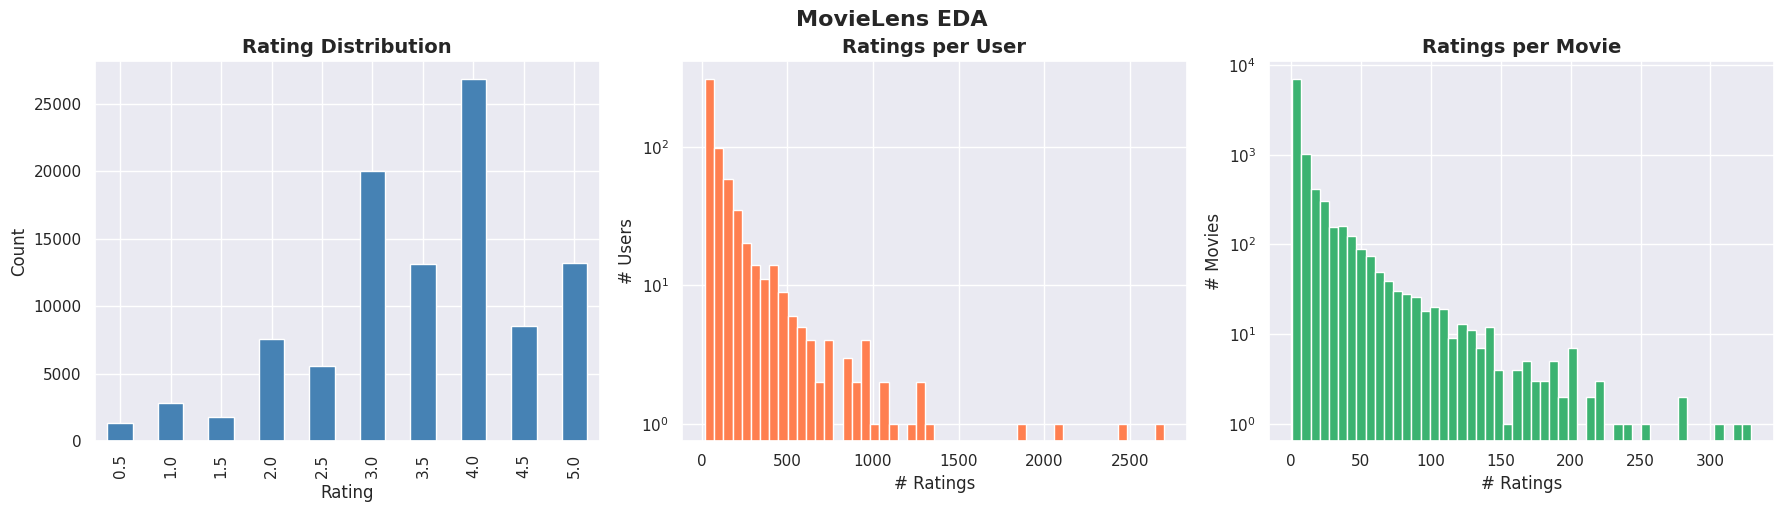


 Unique users  : 610
 Unique movies : 9724
 Total ratings : 100836
 Sparsity      : 98.30%


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Rating distribution
ratings['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# 2. Ratings per user (log scale)
ratings_per_user = ratings.groupby('userId')['rating'].count()
axes[1].hist(ratings_per_user, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Ratings per User', fontsize=14, fontweight='bold')
axes[1].set_xlabel('# Ratings')
axes[1].set_ylabel('# Users')
axes[1].set_yscale('log')

# 3. Ratings per movie (log scale)
ratings_per_movie = ratings.groupby('movieId')['rating'].count()
axes[2].hist(ratings_per_movie, bins=50, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Ratings per Movie', fontsize=14, fontweight='bold')
axes[2].set_xlabel('# Ratings')
axes[2].set_ylabel('# Movies')
axes[2].set_yscale('log')

plt.tight_layout()
plt.suptitle('MovieLens EDA', fontsize=16, fontweight='bold', y=1.02)
plt.show()

print(f'\n Unique users  : {ratings["userId"].nunique()}')
print(f' Unique movies : {ratings["movieId"].nunique()}')
print(f' Total ratings : {len(ratings)}')
print(f' Sparsity      : {1 - len(ratings) / (ratings["userId"].nunique() * ratings["movieId"].nunique()):.2%}')

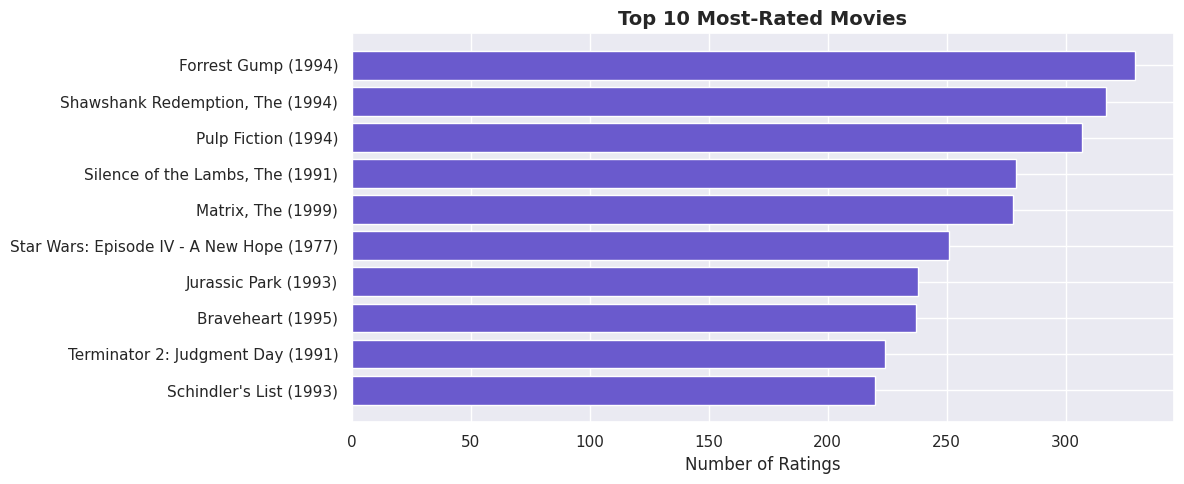

,movieId,num_ratings,avg_rating,title
0,356,329,4.164134,Forrest Gump (1994)
1,318,317,4.429022,"Shawshank Redemption, The (1994)"
2,296,307,4.197068,Pulp Fiction (1994)
3,593,279,4.161290,"Silence of the Lambs, The (1991)"
4,2571,278,4.192446,"Matrix, The (1999)"
5,260,251,4.231076,Star Wars: Episode IV - A New Hope (1977)
6,480,238,3.750000,Jurassic Park (1993)
7,110,237,4.031646,Braveheart (1995)
8,589,224,3.970982,Terminator 2: Judgment Day (1991)
9,527,220,4.225000,Schindler's List (1993)


In [ ]:
# Top 10 most-rated movies
top_movies = (
    ratings.groupby('movieId')['rating']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'num_ratings', 'mean': 'avg_rating'})
    .merge(movies[['movieId', 'title']], on='movieId')
    .sort_values('num_ratings', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_movies['title'], top_movies['num_ratings'], color='slateblue', edgecolor='white')
ax.set_xlabel('Number of Ratings')
ax.set_title('Top 10 Most-Rated Movies', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
display(top_movies.reset_index(drop=True))

In [ ]:
# Filter: keep movies with ≥ 10 ratings and users with ≥ 10 ratings
min_ratings = 10
movie_counts = ratings['movieId'].value_counts()
user_counts  = ratings['userId'].value_counts()

filtered = ratings[
    ratings['movieId'].isin(movie_counts[movie_counts >= min_ratings].index) &
    ratings['userId'].isin(user_counts[user_counts >= min_ratings].index)
]
print(f'Filtered ratings: {len(filtered)} (from {len(ratings)})')

# Pivot: rows = users, columns = movies, values = ratings
user_movie_matrix = filtered.pivot_table(
    index='userId', columns='movieId', values='rating'
)

# Fill NaN with 0 (unrated = 0)
user_movie_filled = user_movie_matrix.fillna(0)

print(f'\nUser-Movie matrix shape: {user_movie_filled.shape}')
print(f'Sparsity after filter  : {(user_movie_filled == 0).sum().sum() / user_movie_filled.size:.2%}')

# Convert to sparse matrix for efficiency
sparse_matrix = csr_matrix(user_movie_filled.values)
print('\n Sparse matrix ready')

Filtered ratings: 81116 (from 100836)

User-Movie matrix shape: (610, 2269)
Sparsity after filter  : 94.14%

 Sparse matrix ready


SVD with 50 components:
  Total variance explained: 54.62%


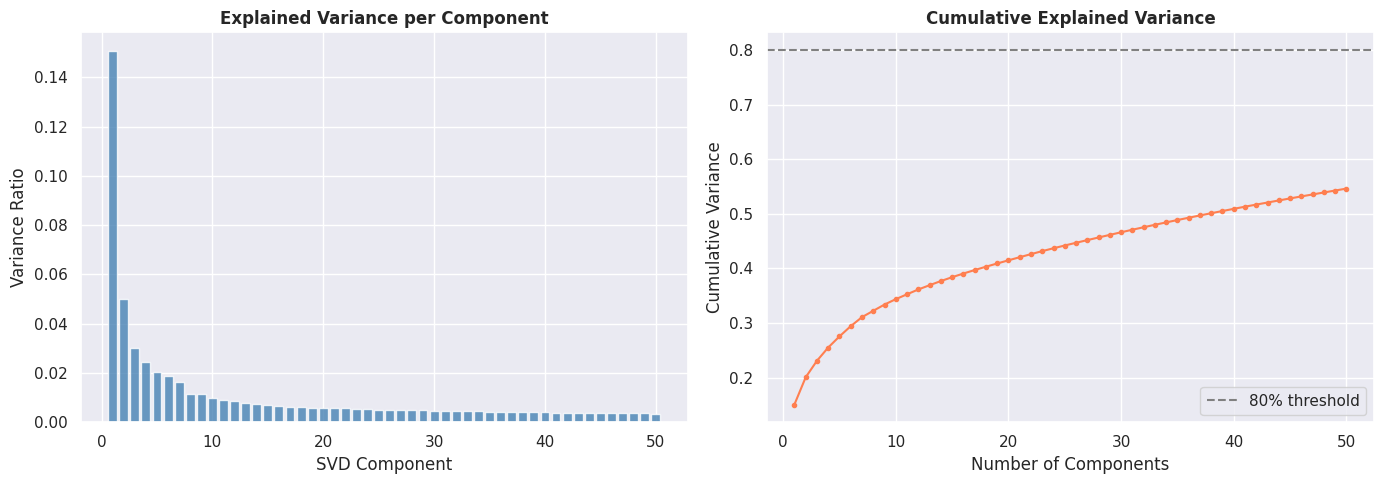


 User latent factor matrix shape: (610, 50)


In [ ]:
# --- Truncated SVD to extract latent factors ---
N_COMPONENTS = 50  # latent dimensions

svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
user_factors = svd.fit_transform(sparse_matrix)   # shape: (users, 50)

explained_var = svd.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print(f'SVD with {N_COMPONENTS} components:')
print(f'  Total variance explained: {cumulative_var[-1]:.2%}')

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, N_COMPONENTS + 1), explained_var, color='steelblue', alpha=0.8)
axes[0].set_title('Explained Variance per Component', fontweight='bold')
axes[0].set_xlabel('SVD Component')
axes[0].set_ylabel('Variance Ratio')

axes[1].plot(range(1, N_COMPONENTS + 1), cumulative_var, marker='o', markersize=3, color='coral')
axes[1].axhline(y=0.8, color='gray', linestyle='--', label='80% threshold')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

# Normalize user factors for cosine similarity later
user_factors_norm = normalize(user_factors)
print('\n User latent factor matrix shape:', user_factors_norm.shape)

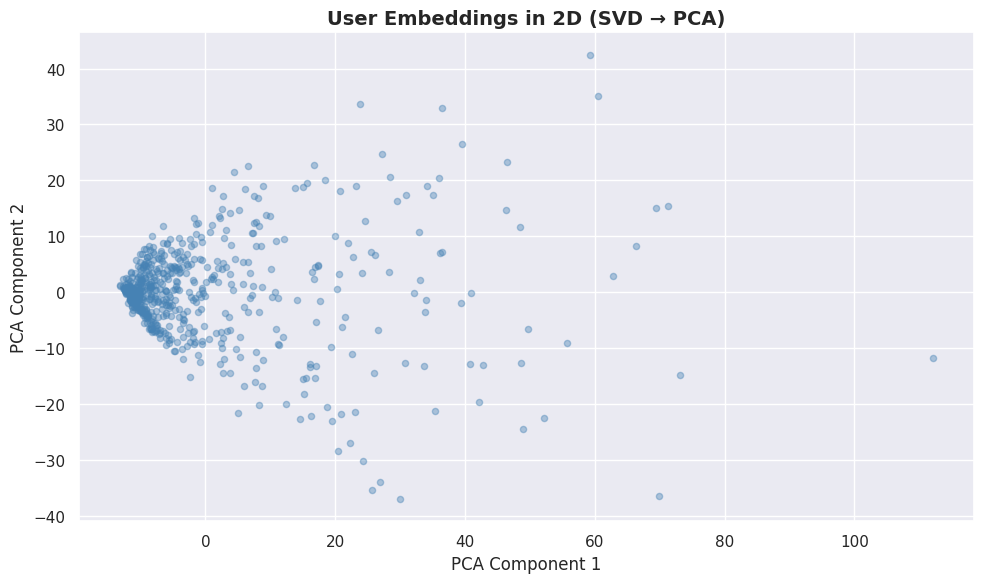

In [ ]:
# --- PCA on top of SVD factors for 2D visualization ---
pca = PCA(n_components=2, random_state=42)
user_2d = pca.fit_transform(user_factors)

plt.figure(figsize=(10, 6))
plt.scatter(user_2d[:, 0], user_2d[:, 1], alpha=0.4, s=20, color='steelblue')
plt.title('User Embeddings in 2D (SVD → PCA)', fontsize=14, fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.show()

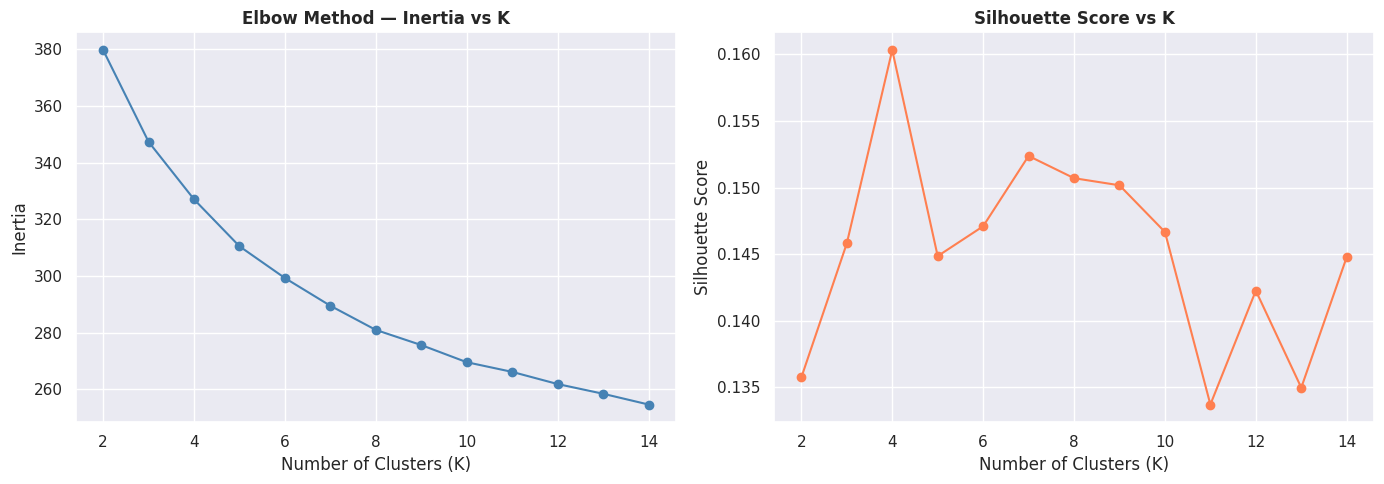


 Best K by silhouette score: 4


In [ ]:
# --- Elbow Method to find optimal K ---
inertias     = []
sil_scores   = []
K_range      = range(2, 15)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(user_factors_norm)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(user_factors_norm, labels, sample_size=500))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'o-', color='steelblue')
axes[0].set_title('Elbow Method — Inertia vs K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, 'o-', color='coral')
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(sil_scores)]
print(f'\n Best K by silhouette score: {best_k}')

In [ ]:
# --- Final KMeans clustering ---
BEST_K = best_k  # or manually set, e.g. BEST_K = 6

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(user_factors_norm)

# Attach cluster labels to users
user_clusters = pd.DataFrame({
    'userId' : user_movie_filled.index,
    'cluster': cluster_labels
})

print(f'Cluster distribution:')
print(user_clusters['cluster'].value_counts().sort_index())

Cluster distribution:
cluster
0    242
1    242
2     27
3     99
Name: count, dtype: int64


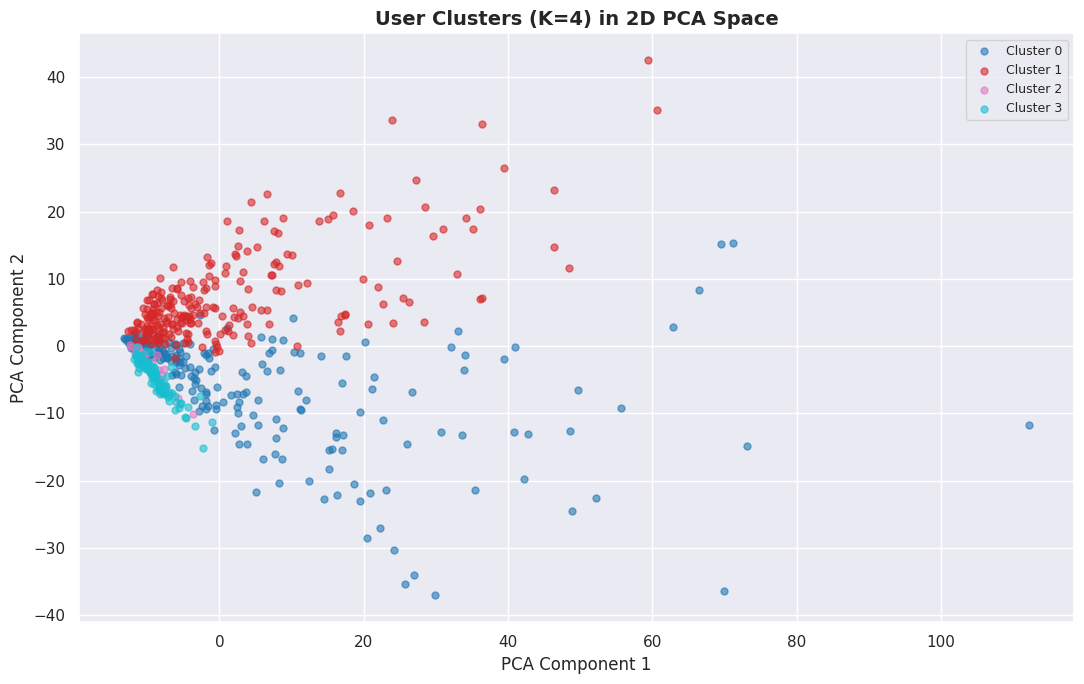

In [ ]:
# --- Visualize clusters in 2D ---
colors = plt.cm.tab10(np.linspace(0, 1, BEST_K))

plt.figure(figsize=(11, 7))
for c in range(BEST_K):
    mask = cluster_labels == c
    plt.scatter(user_2d[mask, 0], user_2d[mask, 1],
                label=f'Cluster {c}', alpha=0.6, s=25, color=colors[c])

plt.title(f'User Clusters (K={BEST_K}) in 2D PCA Space', fontsize=14, fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# Add cluster labels to the ratings data
ratings_clustered = filtered.merge(user_clusters, on='userId')

# Merge movie info
ratings_clustered = ratings_clustered.merge(movies[['movieId', 'title', 'genres']], on='movieId')

# Top 5 genres per cluster
def top_genres(df, n=5):
    genre_series = df['genres'].str.split('|').explode()
    return genre_series.value_counts().head(n)

print('=== TOP GENRES PER CLUSTER ===')
for c in sorted(user_clusters['cluster'].unique()):
    cluster_df = ratings_clustered[ratings_clustered['cluster'] == c]
    n_users = cluster_df['userId'].nunique()
    avg_rating = cluster_df['rating'].mean()
    print(f'\n Cluster {c}  ({n_users} users, avg rating={avg_rating:.2f})')
    print(top_genres(cluster_df).to_string())

=== TOP GENRES PER CLUSTER ===

 Cluster 0  (242 users, avg rating=3.51)
genres
Comedy       17541
Drama        17439
Action       13172
Thriller     11467
Adventure    10458

 Cluster 1  (242 users, avg rating=3.66)
genres
Drama        12657
Action       11586
Comedy       11048
Adventure     9625
Thriller      8773

 Cluster 2  (27 users, avg rating=3.76)
genres
Comedy       443
Drama        394
Thriller     389
Action       368
Adventure    324

 Cluster 3  (99 users, avg rating=3.56)
genres
Drama        2466
Comedy       2189
Thriller     2074
Action       2073
Adventure    1503


In [ ]:
# ----------------------------------------------------------------
# APPROACH: Item-based collaborative filtering using SVD factors
# We reconstruct item embeddings from SVD decomposition
# ----------------------------------------------------------------

# Get movie (item) latent factors from SVD
item_factors = svd.components_.T   # shape: (movies, 50)
item_factors_norm = normalize(item_factors)

# Build movie index mapping
movie_ids    = user_movie_filled.columns.tolist()   # ordered movieIds
movieid_to_idx = {mid: i for i, mid in enumerate(movie_ids)}
idx_to_movieid = {i: mid for mid, i in movieid_to_idx.items()}

# Movie lookup: movieId → title
movie_title_map = movies.set_index('movieId')['title'].to_dict()

print(f'Item factor matrix shape: {item_factors_norm.shape}')


Item factor matrix shape: (2269, 50)


In [ ]:
def get_similar_movies(movie_title_query, top_n=10):
    """
    Find movies most similar to a given movie using cosine similarity
    on SVD item embeddings.
    """
    # Find movieId by partial title match
    match = movies[movies['title'].str.contains(movie_title_query, case=False, na=False)]
    if match.empty:
        print(f' Movie "{movie_title_query}" not found.')
        return None

    movie_id = match.iloc[0]['movieId']
    title    = match.iloc[0]['title']

    if movie_id not in movieid_to_idx:
        print(f'  "{title}" is in dataset but was filtered out (too few ratings).')
        return None

    idx = movieid_to_idx[movie_id]
    query_vec = item_factors_norm[idx].reshape(1, -1)

    # Compute cosine similarity with all movies
    sims = cosine_similarity(query_vec, item_factors_norm)[0]

    # Sort and exclude the query movie itself
    top_indices = np.argsort(sims)[::-1][1: top_n + 1]

    results = []
    for i in top_indices:
        mid = idx_to_movieid[i]
        results.append({
            'movieId'    : mid,
            'title'      : movie_title_map.get(mid, f'ID:{mid}'),
            'similarity' : round(sims[i], 4)
        })

    result_df = pd.DataFrame(results)
    print(f'\n Movies similar to: "{title}"\n')
    display(result_df)
    return result_df


# --- Try it out ---
get_similar_movies('Toy Story')


 Movies similar to: "Toy Story (1995)"



,movieId,title,similarity
0,9,Sudden Death (1995),0.5121
1,810,Kazaam (1996),0.4770
2,3114,Toy Story 2 (1999),0.4675
3,4306,Shrek (2001),0.4661
4,836,Chain Reaction (1996),0.4605
5,134853,Inside Out (2015),0.4465
6,786,Eraser (1996),0.4299
7,2355,"Bug's Life, A (1998)",0.4295
8,79,"Juror, The (1996)",0.4275
9,761,"Phantom, The (1996)",0.4240


,movieId,title,similarity
0,9,Sudden Death (1995),0.5121
1,810,Kazaam (1996),0.4770
2,3114,Toy Story 2 (1999),0.4675
3,4306,Shrek (2001),0.4661
4,836,Chain Reaction (1996),0.4605
5,134853,Inside Out (2015),0.4465
6,786,Eraser (1996),0.4299
7,2355,"Bug's Life, A (1998)",0.4295
8,79,"Juror, The (1996)",0.4275
9,761,"Phantom, The (1996)",0.4240


In [ ]:
def recommend_for_user(user_id, top_n=10):
    """
    Recommend movies for a specific user based on their SVD latent vector
    by computing similarity to all item embeddings.
    Unseen movies are ranked by predicted preference score.
    """
    if user_id not in user_movie_filled.index:
        print(f' User {user_id} not in matrix (may have been filtered out).')
        return None

    user_idx = list(user_movie_filled.index).index(user_id)
    user_vec = user_factors_norm[user_idx].reshape(1, -1)

    # Score all movies
    scores = cosine_similarity(user_vec, item_factors_norm)[0]

    # Exclude already-rated movies
    rated_ids = set(
        filtered[filtered['userId'] == user_id]['movieId'].tolist()
    )

    # Build ranked list of unseen movies
    recs = []
    for i, score in enumerate(scores):
        mid = idx_to_movieid[i]
        if mid not in rated_ids:
            recs.append({
                'movieId': mid,
                'title'  : movie_title_map.get(mid, f'ID:{mid}'),
                'score'  : round(score, 4)
            })

    rec_df = pd.DataFrame(recs).sort_values('score', ascending=False).head(top_n)
    print(f'\n Top {top_n} recommendations for User {user_id}\n')
    display(rec_df.reset_index(drop=True))
    return rec_df


# --- Try it out with a random user ---
sample_user = user_movie_filled.index[0]
recommend_for_user(sample_user)


 Top 10 recommendations for User 1



,movieId,title,score
0,2085,101 Dalmatians (One Hundred and One Dalmatians...,0.3487
1,1036,Die Hard (1988),0.2859
2,69,Friday (1995),0.2730
3,2527,Westworld (1973),0.2721
4,3704,Mad Max Beyond Thunderdome (1985),0.2698
5,3256,Patriot Games (1992),0.2534
6,1405,Beavis and Butt-Head Do America (1996),0.2473
7,2530,Beneath the Planet of the Apes (1970),0.2446
8,2135,Doctor Dolittle (1967),0.2443
9,2746,Little Shop of Horrors (1986),0.2442


,movieId,title,score
668,2085,101 Dalmatians (One Hundred and One Dalmatians...,0.3487
357,1036,Die Hard (1988),0.2859
37,69,Friday (1995),0.2730
787,2527,Westworld (1973),0.2721
1040,3704,Mad Max Beyond Thunderdome (1985),0.2698
944,3256,Patriot Games (1992),0.2534
507,1405,Beavis and Butt-Head Do America (1996),0.2473
788,2530,Beneath the Planet of the Apes (1970),0.2446
688,2135,Doctor Dolittle (1967),0.2443
837,2746,Little Shop of Horrors (1986),0.2442


In [ ]:
def recommend_for_cluster(cluster_id, top_n=10):
    """
    Recommend top movies for an entire user cluster.
    Averages the latent vectors of all users in the cluster,
    then finds the most similar movies.
    """
    cluster_user_ids = user_clusters[user_clusters['cluster'] == cluster_id]['userId'].tolist()
    cluster_user_ids_in_matrix = [
        uid for uid in cluster_user_ids if uid in user_movie_filled.index
    ]

    if not cluster_user_ids_in_matrix:
        print(f' No valid users found for cluster {cluster_id}.')
        return None

    # Get indices of cluster users in the factor matrix
    all_users = list(user_movie_filled.index)
    indices   = [all_users.index(uid) for uid in cluster_user_ids_in_matrix]

    # Average user vector for the cluster
    cluster_vec = user_factors_norm[indices].mean(axis=0).reshape(1, -1)

    # Score all movies
    scores = cosine_similarity(cluster_vec, item_factors_norm)[0]
    top_indices = np.argsort(scores)[::-1][:top_n]

    recs = [{
        'movieId': idx_to_movieid[i],
        'title'  : movie_title_map.get(idx_to_movieid[i], f'ID:{idx_to_movieid[i]}'),
        'score'  : round(scores[i], 4)
    } for i in top_indices]

    rec_df = pd.DataFrame(recs)
    print(f'\n Top {top_n} movies for Cluster {cluster_id} ({len(cluster_user_ids_in_matrix)} users)\n')
    display(rec_df)
    return rec_df


# --- Recommend for each cluster ---
for c in range(BEST_K):
    recommend_for_cluster(c, top_n=5)


 Top 5 movies for Cluster 0 (242 users)



,movieId,title,score
0,2858,American Beauty (1999),0.3322
1,1196,Star Wars: Episode V - The Empire Strikes Back...,0.3234
2,2716,Ghostbusters (a.k.a. Ghost Busters) (1984),0.3164
3,2628,Star Wars: Episode I - The Phantom Menace (1999),0.3144
4,260,Star Wars: Episode IV - A New Hope (1977),0.3050



 Top 5 movies for Cluster 1 (242 users)



,movieId,title,score
0,2959,Fight Club (1999),0.5246
1,79132,Inception (2010),0.4910
2,2571,"Matrix, The (1999)",0.4779
3,58559,"Dark Knight, The (2008)",0.4616
4,7153,"Lord of the Rings: The Return of the King, The...",0.4051



 Top 5 movies for Cluster 2 (27 users)



,movieId,title,score
0,9,Sudden Death (1995),0.8677
1,786,Eraser (1996),0.8145
2,79,"Juror, The (1996)",0.7991
3,736,Twister (1996),0.7962
4,95,Broken Arrow (1996),0.7809



 Top 5 movies for Cluster 3 (99 users)



,movieId,title,score
0,434,Cliffhanger (1993),0.6427
1,153,Batman Forever (1995),0.6336
2,161,Crimson Tide (1995),0.6272
3,225,Disclosure (1994),0.6261
4,454,"Firm, The (1993)",0.6229


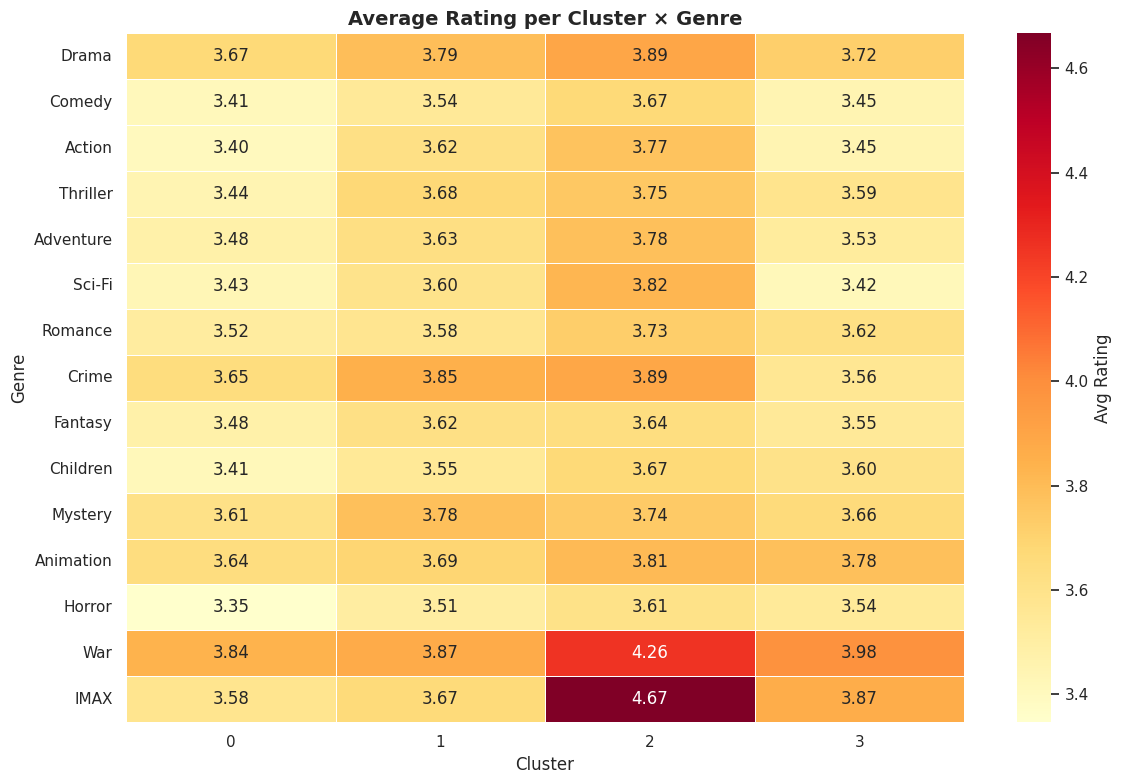

In [ ]:
# Explode genres and pivot
genre_cluster_df = (
    ratings_clustered
    .assign(genre=ratings_clustered['genres'].str.split('|'))
    .explode('genre')
    .groupby(['cluster', 'genre'])['rating']
    .mean()
    .unstack('cluster')
)

# Keep top genres by overall activity
top_genre_list = (
    ratings_clustered
    .assign(genre=ratings_clustered['genres'].str.split('|')).explode('genre')
    ['genre'].value_counts().head(15).index
)
genre_cluster_df = genre_cluster_df.loc[top_genre_list]

plt.figure(figsize=(12, 8))
sns.heatmap(
    genre_cluster_df,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Avg Rating'}
)
plt.title('Average Rating per Cluster × Genre', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

In [ ]:
print('UNSUPERVISED LEARNING — MOVIELENS SUMMARY')
print()
print(f'Dataset: {len(ratings):,} ratings, {ratings["userId"].nunique()} users, {ratings["movieId"].nunique()} movies')
print(f'After filtering: {len(filtered):,} ratings')
print(f'SVD components: {N_COMPONENTS} (latent factors)')
print(f'Variance kept: {cumulative_var[-1]:.1%}')
print(f'KMeans clusters: {BEST_K} (best silhouette)')
print(f'Recommender: Cosine similarity on SVD embeddings')
print()
print('Key Insights:')
print('SVD reveals hidden taste dimensions (latent factors)')
print('Users cluster into distinct preference groups')
print('Each cluster has different genre preferences')
print('Cosine similarity gives accurate personalized recs')


UNSUPERVISED LEARNING — MOVIELENS SUMMARY

Dataset: 100,836 ratings, 610 users, 9724 movies
After filtering: 81,116 ratings
SVD components: 50 (latent factors)
Variance kept: 54.6%
KMeans clusters: 4 (best silhouette)
Recommender: Cosine similarity on SVD embeddings

Key Insights:
SVD reveals hidden taste dimensions (latent factors)
Users cluster into distinct preference groups
Each cluster has different genre preferences
Cosine similarity gives accurate personalized recs
